# 06 · Organocatalysis — transferring a TS across scaffolds

The capability the whole design is built for: **take a known catalytic geometry and transfer its conserved reacting core onto a different catalyst backbone.** Here the **isothiourea** family (tetramisole → BTM → HyperBTM) — Lewis-base acyl-transfer catalysts sharing an amidine–thioether core that activates substrates through an **S···C=O chalcogen bond**. Swap the backbone, conserve the core. Renders highlight the conserved core; the S···O contact is an NCI (`nci_bonds`, dotted); a real TS's reacting bonds use `ts_bonds` (dashed).

In [1]:
import tempfile
import numpy as np
import rxembed as rx
import xyzrender
from rdkit import Chem, RDLogger
from rdkit.Chem import rdMolTransforms as T
from rxembed.embed.dispatch import _xyz_to_mol

RDLogger.DisableLog("rdApp.*")
rx.set_verbose("INFO")
CATALYSTS = {  # the isothiourea family — all share the amidine-thioether core
    "tetramisole": "C1CN2C(=NC1c1ccccc1)Sc1ccccc12",
    "BTM": "C1CN2C(=NC1c1ccccc1)Sc1ccccc12",
    "HyperBTM": "CC(C)[C@]1CN2C(=N[C@]1c1ccccc1)Sc1ccccc12",
}
CORE = "[#7][#6]([#16])=[#7]"  # the conserved amidine-thioether reacting core (N-C(S)=N)


def core_idx(mol):
    return [i + 1 for i in mol.GetSubstructMatch(Chem.MolFromSmarts(CORE))]  # 1-based, for highlight

## The catalyst family

Each backbone embeds and conformer-searches like anything else; the highlighted amidine–thioether core does the chemistry and is conserved across all of them.

rxembed | embed: 13 seeds (33 atoms, 1 fragment, 0 constraints)
rxembed | mc: 5 conformers (openconf 'rapid' drove generation; replaced ETKDG seeds)
rxembed | prune[rmsd]: 5 -> 2  (merged 3 near-duplicates; see .duplicates())
rxembed | embed: 13 seeds (33 atoms, 1 fragment, 0 constraints)
rxembed | mc: 5 conformers (openconf 'rapid' drove generation; replaced ETKDG seeds)
rxembed | prune[rmsd]: 5 -> 3  (merged 2 near-duplicates; see .duplicates())


  tetramisole :  2 conformers (19 heavy atoms)
  BTM         :  3 conformers (19 heavy atoms)


rxembed | embed: 23 seeds (40 atoms, 1 fragment, 0 constraints)
rxembed | mc: 5 conformers (openconf 'rapid' drove generation; replaced ETKDG seeds)
rxembed | prune[rmsd]: 5 -> 4  (merged 1 near-duplicates; see .duplicates())
rxembed | embed: 23 seeds (40 atoms, 1 fragment, 0 constraints)
rxembed | mc: 5 conformers (openconf 'rapid' drove generation; replaced ETKDG seeds)


  HyperBTM    :  4 conformers (22 heavy atoms)


rxembed | prune[rmsd]: 5 -> 4  (merged 1 near-duplicates; see .duplicates())


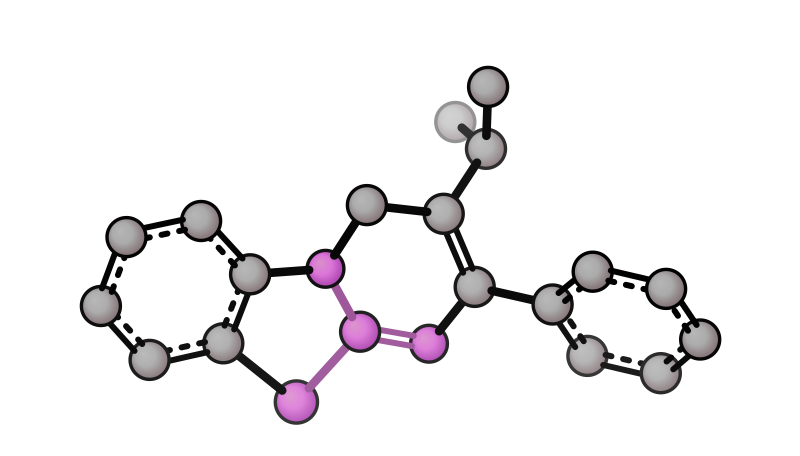

In [2]:
for name, smi in CATALYSTS.items():
    ens = rx.embed(smi).mc(preset="rapid").prune()
    print(f"  {name:12s}: {len(ens):2d} conformers ({Chem.MolFromSmiles(smi).GetNumAtoms()} heavy atoms)")
hb = rx.embed(CATALYSTS["HyperBTM"]).mc(preset="rapid").prune()
xyzrender.render(hb.lowest(1).dump(tempfile.mktemp(suffix=".xyz")), no_hy=True, highlight=core_idx(hb.mol))

## The activation — an S···C=O chalcogen bond

Isothiourea catalysis runs through a chalcogen-bonded acyl-ammonium: the ring **S σ-hole** grips the substrate carbonyl O. Add an acyl donor and let `nci_candidates` find that directional contact.

rxembed | embed: 8 seeds (46 atoms, 2 fragments, 2 constraints)
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run


activation contact: ChB:S12->O21  {(12, 21): (3.0, 3.6)}


rxembed | mc: +5 (openconf 'rapid', pose-constrained around seeds; total 13)
rxembed | prune[rmsd]: 13 -> 10  (merged 3 near-duplicates; see .duplicates())
no bond between atoms 13 and 22 - placing label at midpoint


10 conformers; S···O = 3.60 Å


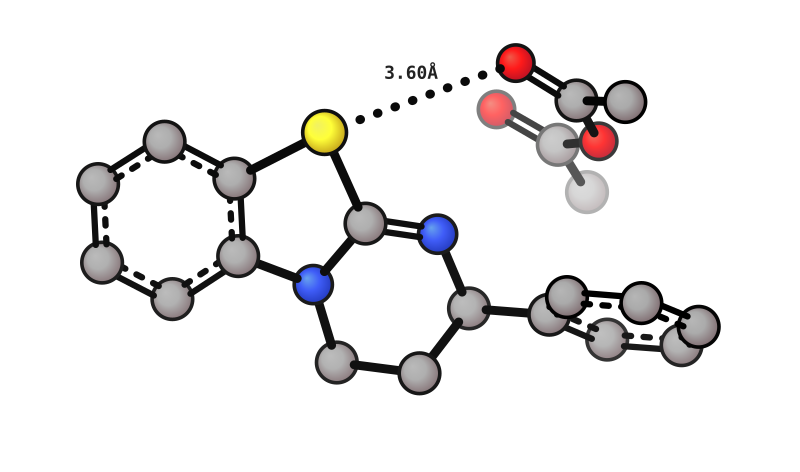

In [3]:
catalyst = CATALYSTS["tetramisole"]
acyl_donor = "CC(=O)OC(C)=O"  # acetic anhydride — the acyl source
complex_smi = f"{catalyst}.{acyl_donor}"
cands = rx.nci_candidates(Chem.AddHs(Chem.MolFromSmiles(complex_smi)))
chb = next(k for k in cands if k.startswith("ChB"))  # the S...O=C chalcogen bond
print(f"activation contact: {chb}  {cands[chb].distances}")
ens = rx.embed(complex_smi, contacts=cands[chb], n=8).mc(preset="rapid").prune()
s, o = next(iter(cands[chb].distances))
print(f"{len(ens)} conformers; S···O = {ens.measure((s, o))['mean']:.2f} Å")
xyzrender.render(
    ens.lowest(1).dump(tempfile.mktemp(suffix=".xyz")),
    no_hy=True,
    nci_bonds=[(s + 1, o + 1)],
    labels=[f"{s + 1} {o + 1} d"],
)  # the chalcogen contact (dotted)

## The backbone swap — the headline

Embed one scaffold (tetramisole), then **transfer its amidine-core geometry onto the other backbones** — `template=` the geometry, `match=` the conserved core. The core is pinned exactly (dev ≈ 0, highlighted) while each new backbone's periphery is searched: one known geometry → a whole catalyst series.

rxembed | embed: 13 seeds (33 atoms, 1 fragment, 0 constraints)
rxembed | mc: 5 conformers (openconf 'rapid' drove generation; replaced ETKDG seeds)
rxembed | prune[rmsd]: 5 -> 4  (merged 1 near-duplicates; see .duplicates())
rxembed | template: matched a 4-atom core; pinning it to the template geometry, conf-searching the rest
rxembed | template embed: 20 seeds, 4-atom core pinned to the template
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run
rxembed | mc: +5 (openconf 'rapid', pose-constrained around seeds; total 25)
rxembed | prune[rmsd]: 25 -> 10  (merged 15 near-duplicates; see .duplicates())
rxembed | template: matched a 4-atom core; pinning it to the template geometry, conf-searching the rest
rxembed | template embed: 39 seeds, 4-atom core pinned to the template
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the d

  tetramisole -> BTM      : 10 confs | conserved amidine core dev 0.0000 Å


rxembed | mc: +5 (openconf 'rapid', pose-constrained around seeds; total 44)
rxembed | prune[rmsd]: 44 -> 27  (merged 17 near-duplicates; see .duplicates())


  tetramisole -> HyperBTM : 27 confs | conserved amidine core dev 0.0000 Å


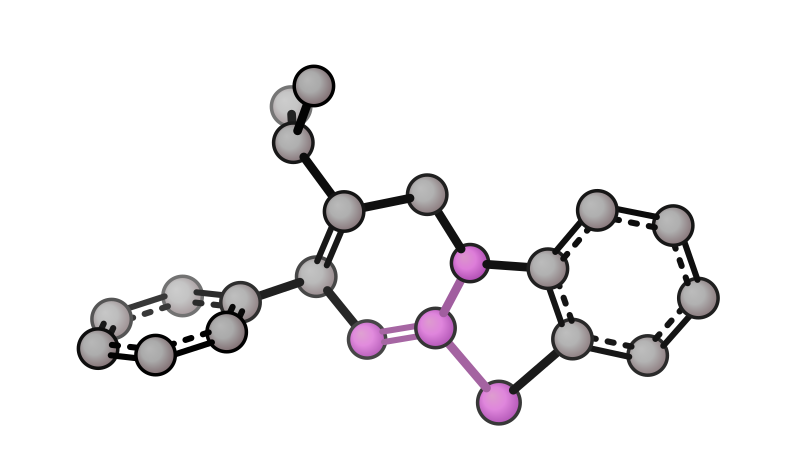

In [4]:
template = rx.embed(CATALYSTS["tetramisole"]).mc(preset="rapid").prune()


def core_dev(ens):
    q = Chem.MolFromSmarts(CORE)
    nm, tm = ens.mol.GetSubstructMatch(q), template.mol.GetSubstructMatch(q)
    tp = template.mol.GetConformer(template.ids[0]).GetPositions()
    pw = lambda p_, ix: sorted(np.linalg.norm(p_[a] - p_[b]) for i, a in enumerate(ix) for b in ix[i + 1 :])
    return max(
        max(abs(x - y) for x, y in zip(pw(ens.mol.GetConformer(c).GetPositions(), nm), pw(tp, tm))) for c in ens.ids
    )


swaps = {}
for name in ["BTM", "HyperBTM"]:
    sw = rx.embed(CATALYSTS[name], template=template, match=CORE).mc(preset="rapid").prune()
    swaps[name] = sw
    print(f"  tetramisole -> {name:9s}: {len(sw):2d} confs | conserved amidine core dev {core_dev(sw):.4f} Å")
sw = swaps["HyperBTM"]
xyzrender.render(sw.lowest(1).dump(tempfile.mktemp(suffix=".xyz")), no_hy=True, highlight=core_idx(sw.mol))

## The same pattern for a real DFT TS

The swap above starts from an embedded scaffold; with a genuine **TS `.xyz`** it is the identical call with `freeze=`. A chiral-phosphoric-acid organocatalysis TS (103 atoms) embeds with its reacting core held to 0.000 Å while the catalyst periphery is searched — the reacting bonds drawn with `ts_bonds`.

rxembed | embed: 2 seeds (103 atoms, 1 fragment, 10 constraints)
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run
rxembed | mc: +5 (openconf 'rapid', pose-constrained around seeds; total 7)
rxembed | prune[rmsd]: 7 -> 7  (merged 0 near-duplicates; see .duplicates())


CPA organocatalysis TS (103 atoms): 7 conformers | reacting core held to 0.0000 Å


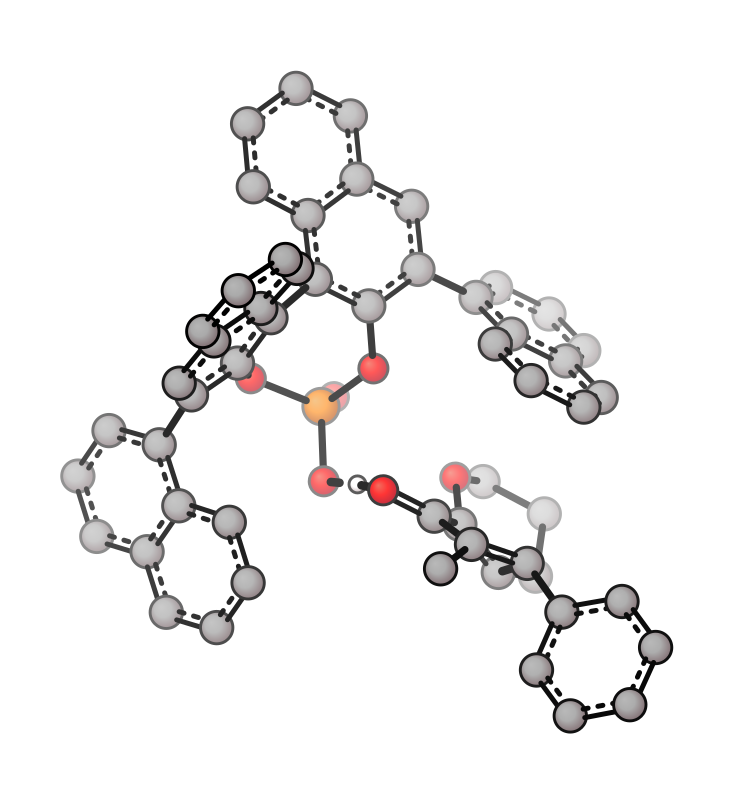

In [5]:
cpa = "structures/cpa.xyz"
rc = [23, 35, 70, 74, 75]  # reacting-core atoms (from a graphrc trajectory in practice)
bonds = [(23, 35), (35, 75), (70, 74)]  # forming / breaking bonds held during embed
ens = rx.embed(cpa, freeze=rc, n=2).mc(preset="rapid").prune()
pin = _xyz_to_mol(cpa, 0).GetConformer().GetPositions()
drift = max(
    abs(T.GetBondLength(ens.mol.GetConformer(c), i, j) - float(np.linalg.norm(pin[i] - pin[j])))
    for c in ens.ids
    for i, j in bonds
)
print(f"CPA organocatalysis TS (103 atoms): {len(ens)} conformers | reacting core held to {drift:.4f} Å")
xyzrender.render(
    ens.lowest(1).dump(tempfile.mktemp(suffix=".xyz")), no_hy=True, ts_bonds=[(i + 1, j + 1) for i, j in bonds]
)